In [81]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('../data/credit_risk_dataset.csv')
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Описание признаков

- **person_age**: Возраст человека, подающего заявку на кредит.

- **person_income**: Годовой доход человека.

- **person_home_ownership**: Тип владения жильём.
  - **rent**: Человек снимает жильё.
  - **mortgage**: У человека есть ипотека на принадлежащее ему жильё.
  - **own**: Человек полностью владеет своим домом (без ипотеки).
  - **other**: Другие категории владения жильём, специфичные для набора данных.

- **person_emp_length**: Стаж работы человека в годах.

- **loan_intent**: Цель получения кредита.

- **loan_grade**: Рейтинг кредита на основе кредитоспособности заёмщика.
  - **A**: Высокая кредитоспособность, низкий риск.
  - **B**: Относительно низкий риск, но не такая высокая кредитоспособность, как у категории A.
  - **C**: Умеренная кредитоспособность.
  - **D**: Повышенный риск по сравнению с предыдущими категориями.
  - **E**: Более низкая кредитоспособность, высокий риск.
  - **F**: Значительный кредитный риск.
  - **G**: Самая низкая кредитоспособность, наивысший риск.

- **loan_amnt**: Запрашиваемая сумма кредита.

- **loan_int_rate**: Процентная ставка по кредиту.

- **loan_status**: Статус кредита, где 0 означает отсутствие дефолта, а 1 — дефолт.
  - **0**: Нет дефолта — заёмщик успешно погасил кредит согласно условиям.
  - **1**: Дефолт — заёмщик не смог погасить кредит согласно условиям и допустил дефолт.

- **loan_percent_income**: Процент дохода, который составляет сумма кредита.

- **cb_person_default_on_file**: История дефолтов человека согласно записям кредитного бюро.
  - **Y**: У человека есть история дефолтов в кредитной истории.
  - **N**: У человека нет истории дефолтов.

- **cb_preson_cred_hist_length**: Длина кредитной истории человека.

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [5]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [101]:
data.isna().sum() 

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

есть пропуски в процентной ставке и стаже работы. эти значения позже заполним медианой

In [103]:
data.duplicated().sum()

np.int64(165)

есть 165 дубликатов, их нужно будет удалить

## Целевая переменная

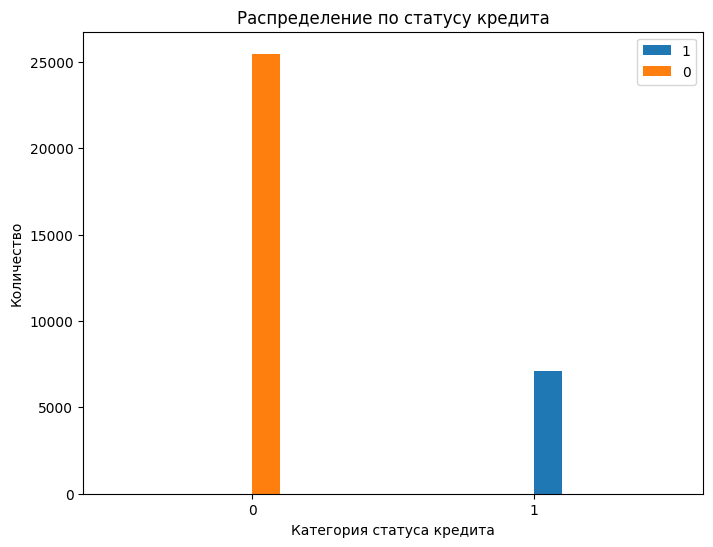

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for c in data['loan_status'].unique():
    ax.hist(data['loan_status'].loc[data['loan_status'] == c], label=c)
    
ax.set_xlabel('Категория статуса кредита')
ax.set_ylabel('Количество')
ax.set_title('Распределение по статусу кредита')
ax.set_xticks(data['loan_status'].unique())
ax.legend()
plt.show()

Как можем заметить, распределение целевой переменной неравномерное

In [26]:
cat_cols = data.select_dtypes(include=['str']).columns.to_list()
num_cols = data.select_dtypes(exclude=['str']).columns.to_list()

num_cols.remove('loan_status')

print("Количество категориальных колонок:", len(cat_cols))
print("Количество числовых колонок:", len(num_cols))

Количество категориальных колонок: 4
Количество числовых колонок: 7


## Категориальные признаки

In [31]:
for cat in cat_cols:
    print(cat, len(data[cat].unique()))

person_home_ownership 4
loan_intent 6
loan_grade 7
cb_person_default_on_file 2


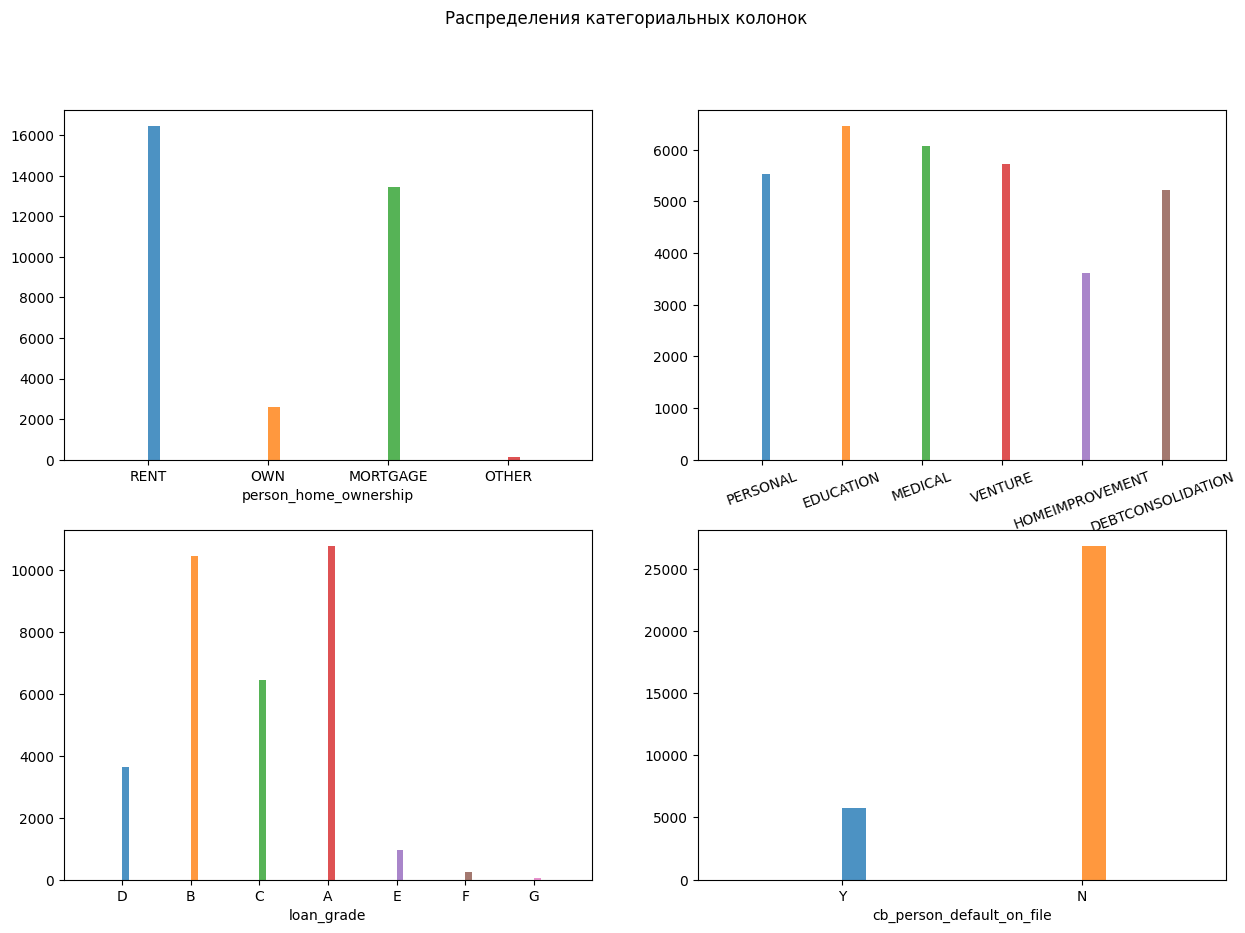

In [60]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

for i, cat in enumerate(cat_cols):
    for c in data[cat].unique():
        axs[i].hist(data[cat].loc[data[cat] == c], label=c, alpha=0.8)
        
    axs[i].set_xlabel(cat)
    axs[i].set_xticks(data[cat].unique())
    if len("".join(data[cat].unique())) > 20:
        axs[i].tick_params(axis='x', rotation=20)

plt.suptitle('Распределения категориальных колонок')
plt.show()

Все признаки могут оказаться информативными для модели

## Числовые признаки

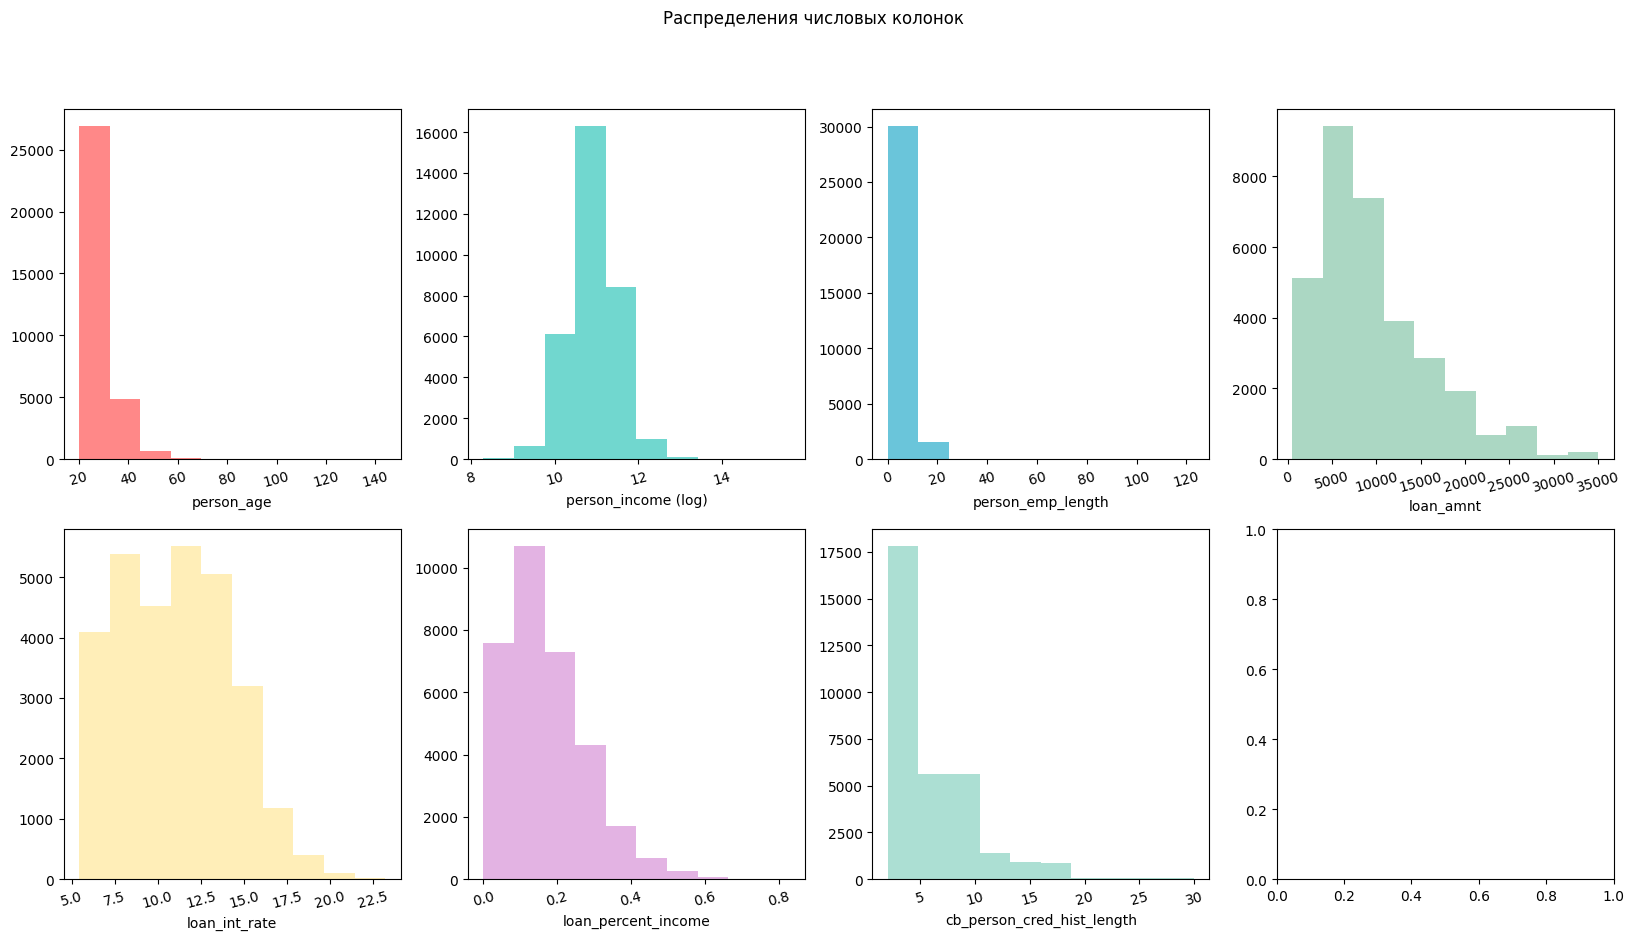

In [66]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs = axs.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', 
          '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F']

for i, num in enumerate(num_cols):
    if num == 'person_income':
        axs[i].hist(data[num].apply(np.log), color=colors[i], alpha=0.8)
        axs[i].set_xlabel(num + ' (log)')
    else:
        axs[i].hist(data[num], color=colors[i], alpha=0.8)
        axs[i].set_xlabel(num)

    axs[i].tick_params(axis='x', rotation=15)

plt.suptitle('Распределения числовых колонок')
plt.show()

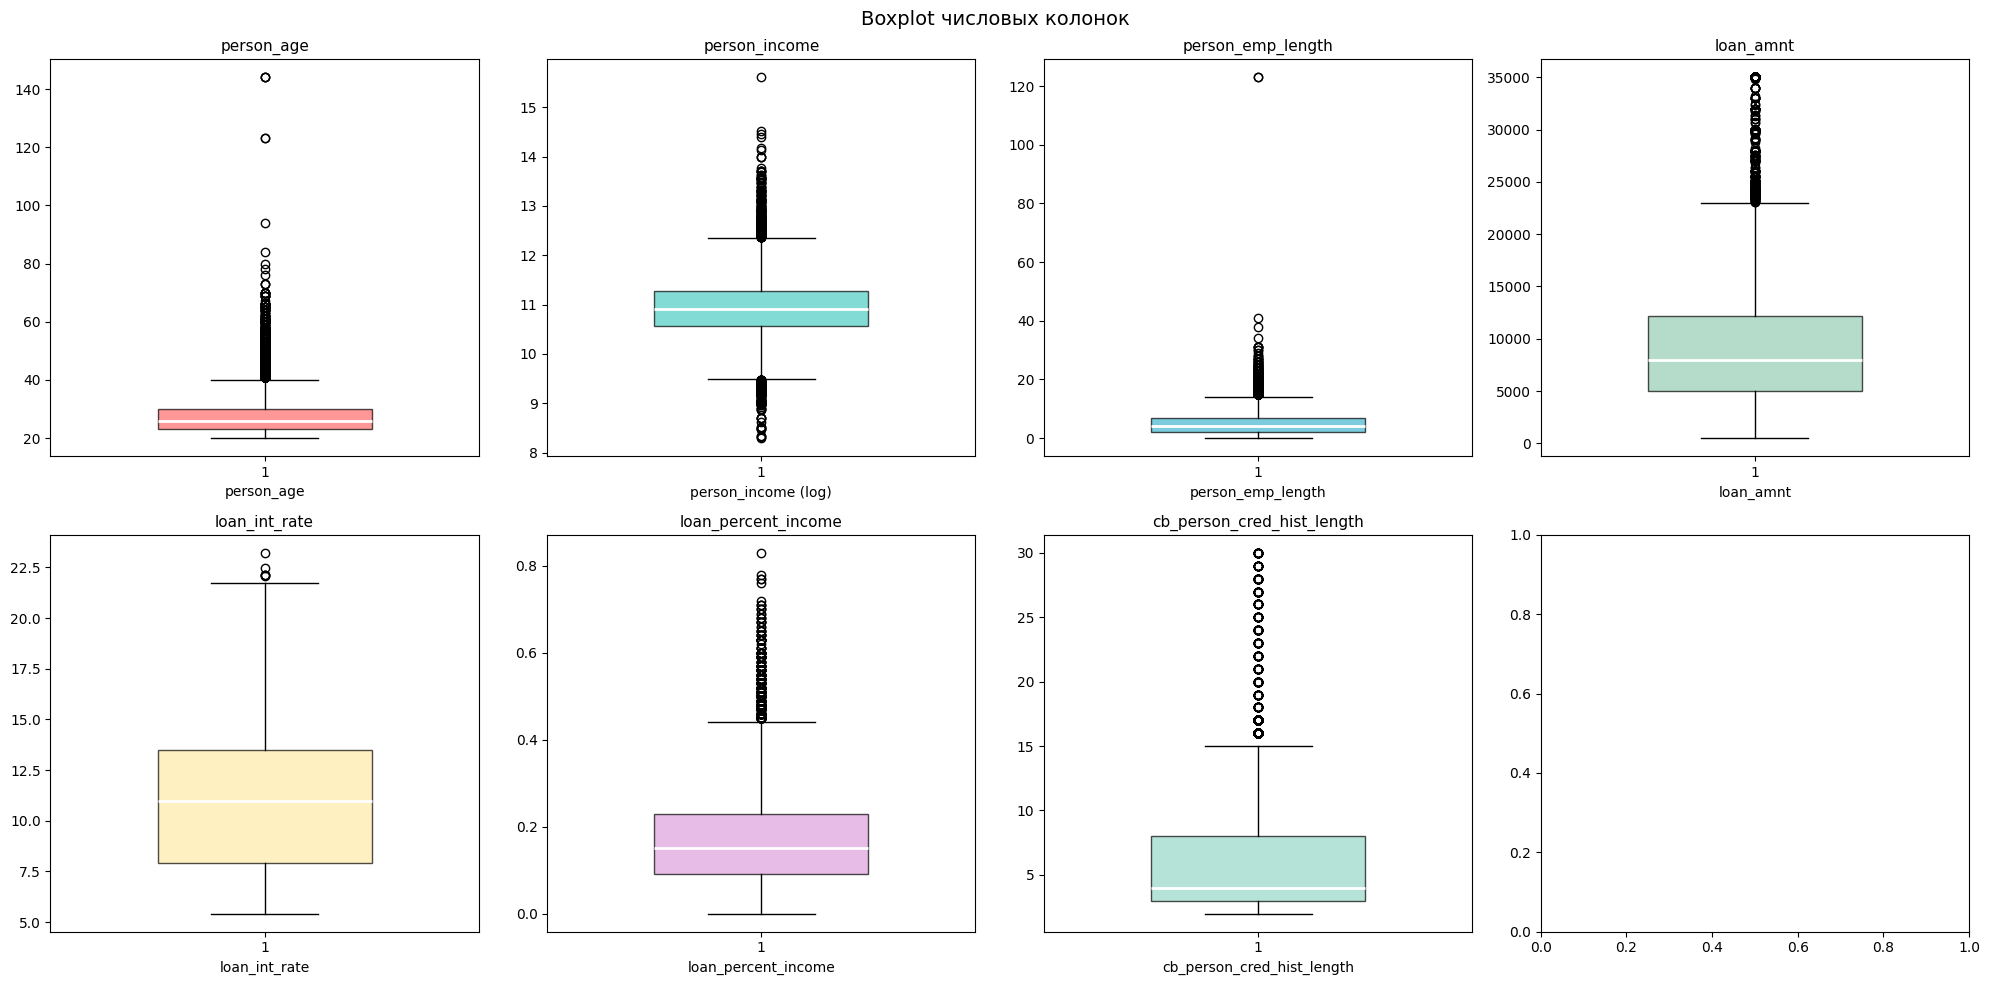

In [69]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs = axs.flatten()

for i, num in enumerate(num_cols):
    
    if num == 'person_income':
        values = data[num].apply(np.log).dropna().values
        label = num + ' (log)'
    else:
        values = data[num].dropna().values
        label = num
    
    bp = axs[i].boxplot(values, patch_artist=True, widths=0.5)
    axs[i].set_xlabel(label)

    for patch in bp['boxes']:
        patch.set_facecolor(colors[i])
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set_color('white')
        median.set_linewidth(2)

    
    axs[i].set_title(num, fontsize=11)

plt.suptitle('Boxplot числовых колонок', fontsize=14)
plt.tight_layout()
plt.show()

В данных присутсвует множество выбросов, а так же многие данные имеют скошенный график. Давайте некотрые из них прологарифмируем и посмотрим, станет ли распределение ближе к нормальному

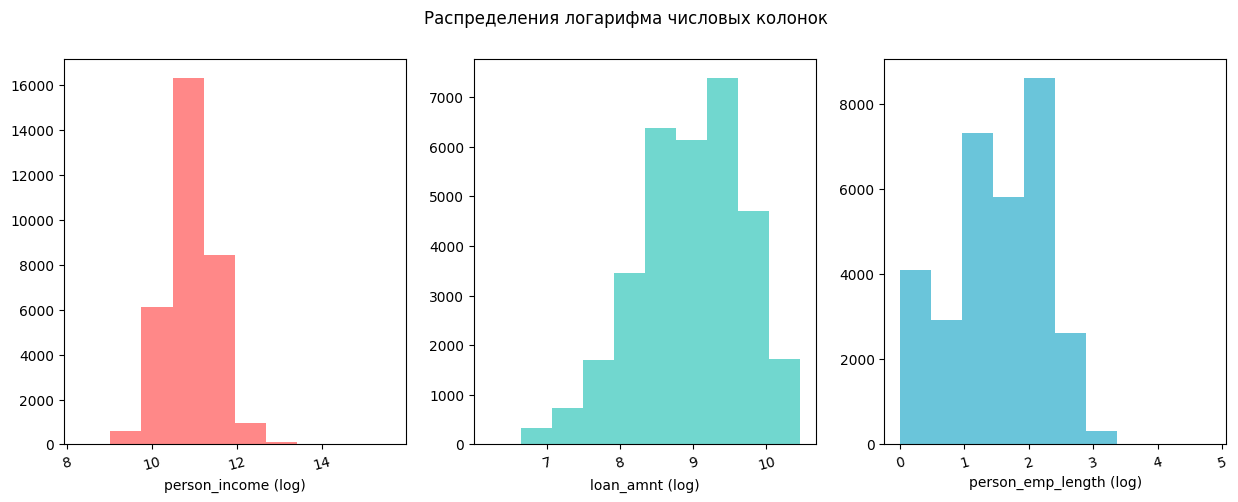

In [79]:
cols_to_log = ['person_income', 'loan_amnt', 'person_emp_length']
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.flatten()


for i, num in enumerate(cols_to_log):
    axs[i].hist(data[num].apply(np.log1p), color=colors[i], alpha=0.8)
    axs[i].set_xlabel(num + ' (log)')


    axs[i].tick_params(axis='x', rotation=15)

plt.suptitle('Распределения логарифма числовых колонок')
plt.show()

Выглядит получше!) Конечно, скорее всего в итоговом решении мы будем пользоваться графдиентным бустингом, где нормальность величин не важна, но для бейзлайна пойдет

## Корреляция

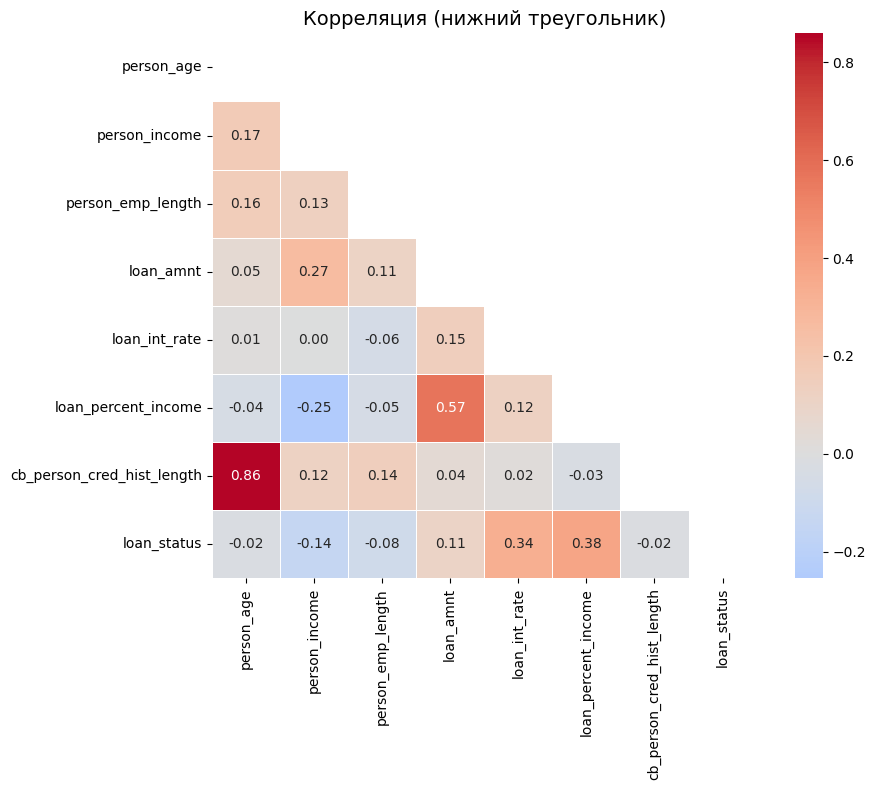

In [ ]:
plt.figure(figsize=(10, 8))
corr = data[num_cols + ['loan_status']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  

sns.heatmap(
    corr,
    mask=mask,            
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Корреляция (нижний треугольник)', fontsize=14)
plt.tight_layout()
plt.show()

сильнее всего с таргетом коррелирует loan_percent_income (процент дохода, который составляет кредит) и loan_int_rate (процентная ставка)

так же между собой сильно коррелируют cb_person_cred_histoty_length и person_age, что может плохо сказаться на линейных моделях

сравним так же с помощью anova:

                      feature      f_score        p_value
5         loan_percent_income  4823.663794   0.000000e+00
4               loan_int_rate  3726.854299   0.000000e+00
1               person_income   571.972136  3.537876e-125
3                   loan_amnt   374.043740   8.326532e-83
2           person_emp_length   196.902227   1.392110e-44
0                  person_age    15.598238   7.851498e-05
6  cb_person_cred_hist_length     7.014775   8.088412e-03


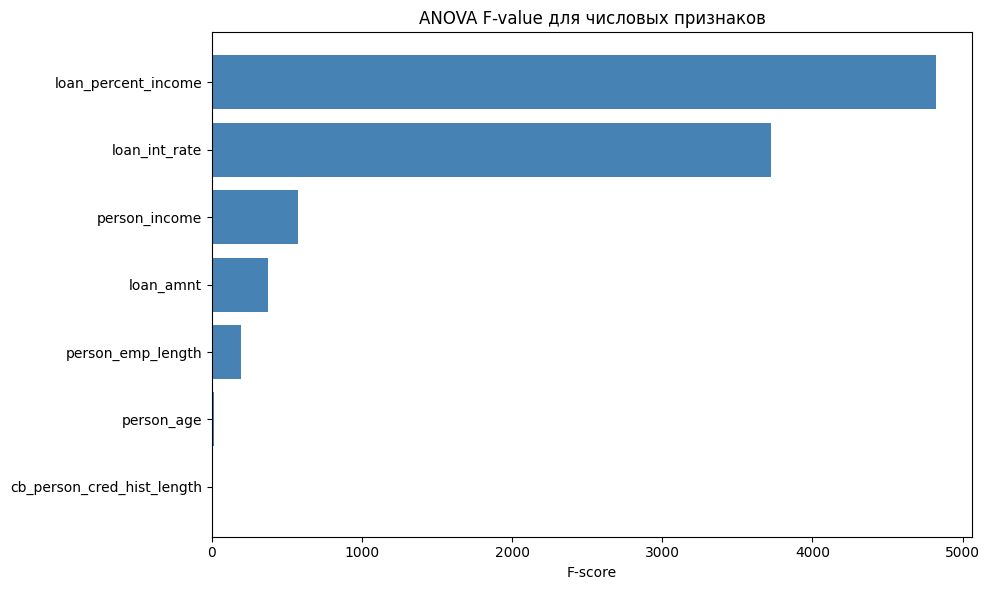

In [ ]:
from sklearn.feature_selection import f_classif

X = data.dropna()[num_cols]
y = data.dropna()['loan_status']

f_scores, p_values = f_classif(X, y)

results = pd.DataFrame({
    'feature': num_cols,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('f_score', ascending=False)

print(results)

plt.figure(figsize=(10, 6))
plt.barh(results['feature'], results['f_score'], color='steelblue')
plt.xlabel('F-score')
plt.title('ANOVA F-value для числовых признаков')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

результаты примерно такие же

для категориальных переменных можем посмотреть на коэффициэнт крамера:

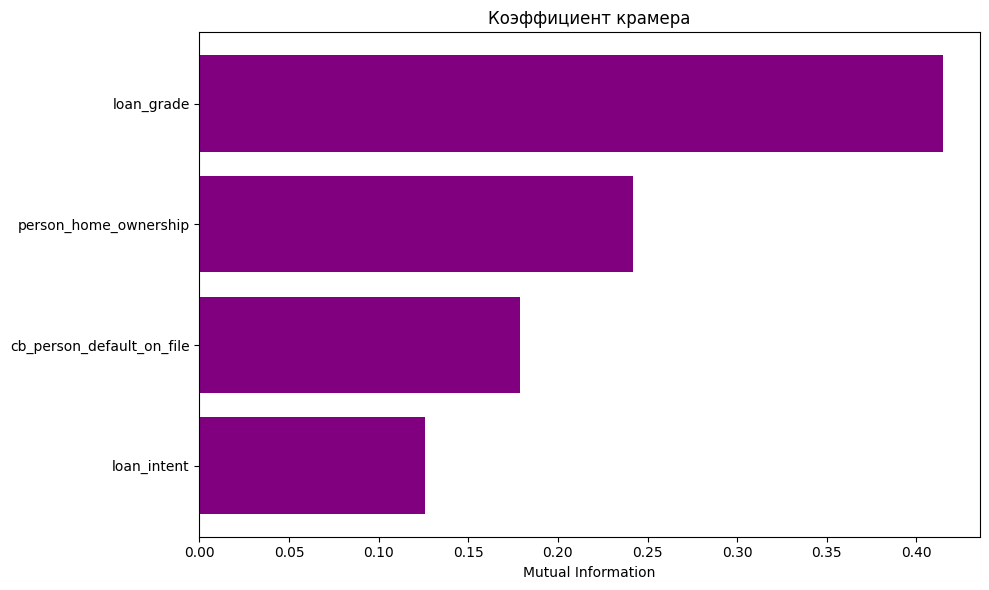

In [95]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

results = []
for col in cat_cols:
    cv = cramers_v(data[col], data['loan_status'])
    results.append({'feature': col, 'cramers_v': cv})

results = pd.DataFrame(results).sort_values('cramers_v', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(results['feature'], results['cramers_v'], color='purple')
plt.xlabel('Mutual Information')
plt.title('Коэффициент крамера')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

из категориальных переменных сильнее всего влияет оценка кредитоспособнсти клиента

для всех типов фич так же можем испробовать метод выделения взаимной информации, он позволяет отследить нелинейные зависимости

                           feature  mi_score
1                    person_income  0.111626
5              loan_percent_income  0.084518
4                    loan_int_rate  0.077272
20                    loan_grade_D  0.041274
10      person_home_ownership_RENT  0.033050
17                    loan_grade_A  0.021719
7   person_home_ownership_MORTGAGE  0.021714
24     cb_person_default_on_file_N  0.018682
3                        loan_amnt  0.013627
21                    loan_grade_E  0.010325
2                person_emp_length  0.009596
25     cb_person_default_on_file_Y  0.009228
16             loan_intent_VENTURE  0.006552
18                    loan_grade_B  0.006486
9        person_home_ownership_OWN  0.006266
23                    loan_grade_G  0.004305
22                    loan_grade_F  0.004262
14             loan_intent_MEDICAL  0.003204
8      person_home_ownership_OTHER  0.001242
0                       person_age  0.000946
6       cb_person_cred_hist_length  0.000000
13     loa

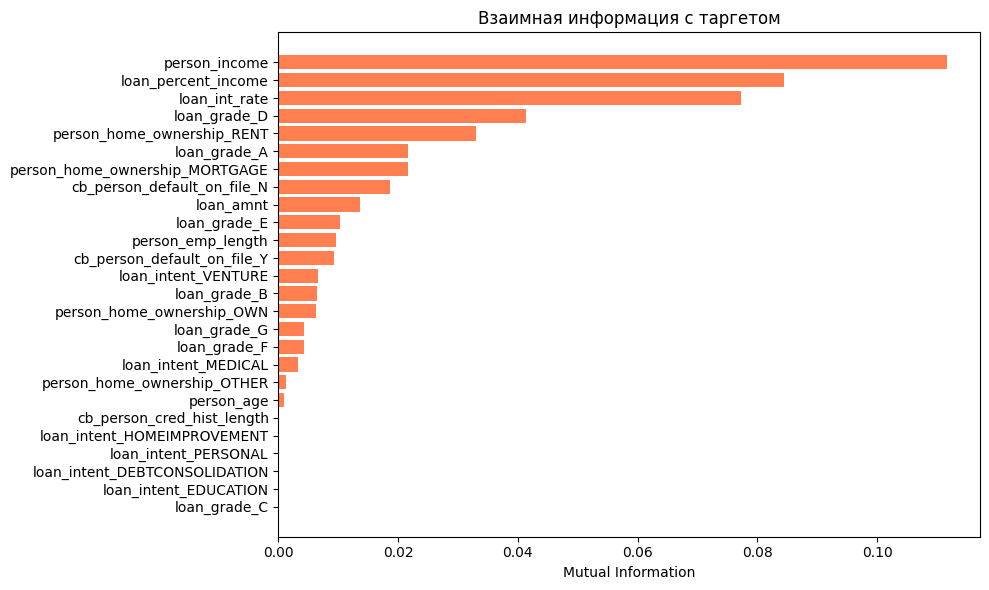

In [98]:
from sklearn.feature_selection import mutual_info_classif

X = pd.get_dummies(data.dropna().drop(columns=['loan_status']))
y = data.dropna()['loan_status']

mi_scores = mutual_info_classif(X, y, random_state=42)

results = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print(results)


plt.figure(figsize=(10, 6))
plt.barh(results['feature'], results['mi_score'], color='coral')
plt.xlabel('Mutual Information')
plt.title('Взаимная информация с таргетом')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

метод поиска взаимной информации ловит нелинейные связи, и здесь к важным признакам добавился person_income (доход)

Самыми неинформативными признаками оказались person_age (возраст) и cb_person_cred_gist_length (длина кредитной истории)  
Опять таки, скорее всего окончательное решение будет сделано с помошью градиентного бусьтнга, где два этих признака никак не повлияют на качество, но для линейного бейзлайна их можно будет удалить (и даже нужно, поскольку они сильно коррелируют между собой)

## Выводы
1. В 'person_emp_length' и 'loan_int_rate' есть пропуски, их необходимо будет заполнить медианой.
2. В данных есть дубликаты, их нужно будет удалить.
3. Таргет неравномерно распределен, при обучении модели желательно использовать, например, разные веса для таргета.
4. 'person_income', 'loan_amnt', 'person_emp_length' необходимо будет прологарифмировать, чтобы приблизить распределение к нормальному
5. Во всех числовых признаках есть выбросы, их необходимо будет удалить
6. 'person_age' и 'cb_person_cred_hist_length' почти неифнормативны, их можно будет удалить